## Latihan Mandiri 3 - Pertemuan 6: Multiprocessing di Python

**Nama: Shahida Shintya   
NIM: 2411511007**


In [1]:
import os
print("Jumlah CPU logis yang terdeteksi pada mesin ini:", os.cpu_count())


Jumlah CPU logis yang terdeteksi pada mesin ini: 1


## 1. Analisis Speedup Skala

**Soal:** Ulangi eksperimen 7.1 (hitung_prima) dengan jumlah worker = 1, 2, 4, 8 (gunakan mp.get_context('fork').Pool(processes=...) agar konsisten). Plot speedup vs jumlah worker, lalu bandingkan dengan kurva Hukum Amdahl dari Pertemuan 1. Jelaskan mengapa kurva aktual mungkin tidak persis mengikuti kurva teoritis.



In [ ]:
import time

def hitung_prima(n):
    # Menghitung semua bilangan prima hingga n (algoritma sederhana, sengaja tidak dioptimasi)
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return len(primes)

# 4 tugas independen, identik dengan bagian 7.1
daftar_n = [80_000, 80_000, 80_000, 80_000]

# Baseline: SEKUENSIAL 
start = time.perf_counter()
hasil_sequential = [hitung_prima(n) for n in daftar_n]
waktu_sequential = time.perf_counter() - start
print(f"[Sequential] hasil: {hasil_sequential}  waktu: {waktu_sequential:.3f} detik")


[Sequential] hasil: [7837, 7837, 7837, 7837]  waktu: 0.250 detik


In [3]:
import multiprocessing as mp

daftar_worker = [1, 2, 4, 8]
waktu_paralel = {}

if __name__ == "__main__":
    for w in daftar_worker:
        start = time.perf_counter()
        with mp.get_context('fork').Pool(processes=w) as pool:
            hasil_paralel = pool.map(hitung_prima, daftar_n)
        waktu = time.perf_counter() - start
        waktu_paralel[w] = waktu
        speedup = waktu_sequential / waktu
        print(f"worker={w} -> waktu: {waktu:.3f} detik | hasil benar: {hasil_paralel == hasil_sequential} | speedup aktual: {speedup:.2f}x")


worker=1 -> waktu: 0.270 detik | hasil benar: True | speedup aktual: 0.87x
worker=2 -> waktu: 0.252 detik | hasil benar: True | speedup aktual: 0.94x
worker=4 -> waktu: 0.246 detik | hasil benar: True | speedup aktual: 0.96x
worker=8 -> waktu: 0.254 detik | hasil benar: True | speedup aktual: 0.93x


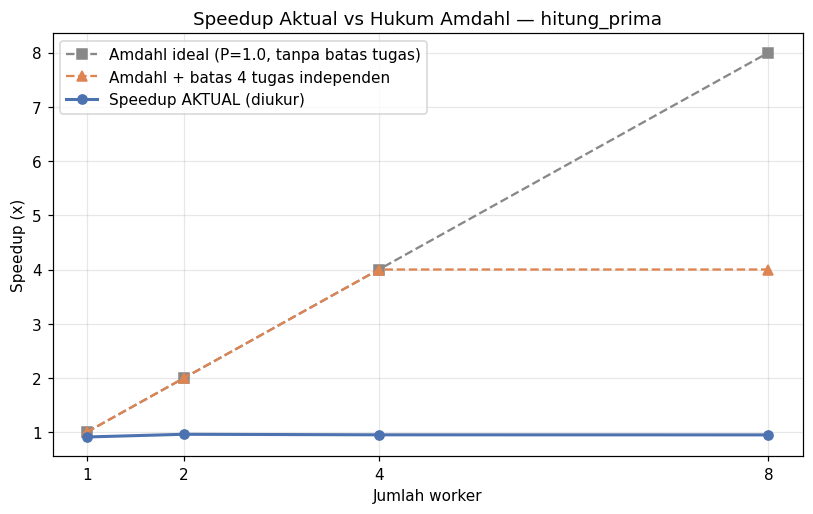

In [4]:
import matplotlib.pyplot as plt

speedup_aktual = [waktu_sequential / waktu_paralel[w] for w in daftar_worker]

# Kurva Hukum Amdahl: speedup = 1 / ((1-P) + P/N)
# P=1.0 -> idealnya linear (speedup = N), tapi hanya ada 4 tugas independen,
# jadi speedup teoritis realistis juga dibatasi oleh jumlah tugas (maks 4).
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)

amdahl_ideal = [amdahl_speedup(1.0, w) for w in daftar_worker]
amdahl_dibatasi_tugas = [min(amdahl_speedup(1.0, w), len(daftar_n)) for w in daftar_worker]

plt.figure(figsize=(7.5, 4.8))
plt.plot(daftar_worker, amdahl_ideal, linestyle='--', marker='s', color="#888888", label="Amdahl ideal (P=1.0, tanpa batas tugas)")
plt.plot(daftar_worker, amdahl_dibatasi_tugas, linestyle='--', marker='^', color="#DD8452", label="Amdahl + batas 4 tugas independen")
plt.plot(daftar_worker, speedup_aktual, marker='o', color="#4C72B0", linewidth=2, label="Speedup AKTUAL (diukur)")
plt.xlabel("Jumlah worker")
plt.ylabel("Speedup (x)")
plt.title("Speedup Aktual vs Hukum Amdahl — hitung_prima")
plt.xticks(daftar_worker)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Analisis:**

Kurva aktual jauh dari kurva Amdahl ideal karena beberapa faktor:

1. Core terbatas: Jumlah worker melebihi core yang tersedia, sehingga proses harus bergantian dan tidak terjadi paralelisme penuh.
2. Overhead proses: Pembuatan dan pengelolaan proses membutuhkan waktu, sehingga mengurangi keuntungan paralelisme.
3. Tugas hanya 4: Worker lebih dari 4 tidak mendapat tugas tambahan, sehingga speedup tidak bertambah.
4. Beban sistem: Proses lain yang berjalan dapat memengaruhi waktu pengukuran.

 Hukum Amdahl merupakan batas teoritis. Speedup aktual dapat jauh lebih rendah karena keterbatasan core, overhead, jumlah tugas, dan beban sistem.


## 2. Shared Memory vs Message Passing

**Soal:** Buat dua versi program yang menghitung total dari 4 proses yang masing-masing menjumlahkan 1 juta angka acak: (a) versi menggunakan Queue (message passing, setiap proses kirim subtotal lewat queue, main process menjumlahkan), dan (b) versi menggunakan Value (shared memory dengan Lock, setiap proses langsung menambah ke shared value). Ukur dan bandingkan waktu eksekusi keduanya.



In [5]:
import multiprocessing as mp
import random
import time

JUMLAH_PROSES = 4
JUMLAH_ANGKA = 1_000_000

def kerja_lokal(seed):
    # Setiap proses membangkitkan & menjumlahkan 1 juta angka acaknya SENDIRI
    rnd = random.Random(seed)
    return sum(rnd.random() for _ in range(JUMLAH_ANGKA))


In [ ]:
# (a) Message Passing dengan Queue =====
def worker_queue(seed, q):
    subtotal = kerja_lokal(seed)
    q.put(subtotal)

if __name__ == "__main__":
    q = mp.Queue()
    start = time.perf_counter()

    proses = [mp.Process(target=worker_queue, args=(seed, q)) for seed in range(JUMLAH_PROSES)]
    for p in proses:
        p.start()

    subtotal_list = [q.get() for _ in range(JUMLAH_PROSES)]   # main process ambil semua subtotal

    for p in proses:
        p.join()

    total_queue = sum(subtotal_list)
    waktu_queue = time.perf_counter() - start

    print(f"[Queue] total         : {total_queue:,.2f}")
    print(f"[Queue] waktu eksekusi: {waktu_queue:.3f} detik")


[Queue] total         : 2,000,251.49
[Queue] waktu eksekusi: 0.275 detik


In [ ]:
# (b) Shared Memory dengan Value + Lock =====
def worker_value(seed, shared_total, lock):
    subtotal = kerja_lokal(seed)
    with lock:
        shared_total.value += subtotal   # setiap proses LANGSUNG menambah ke shared value

if __name__ == "__main__":
    shared_total = mp.Value('d', 0.0)   # 'd' = double
    lock = mp.Lock()
    start = time.perf_counter()

    proses = [mp.Process(target=worker_value, args=(seed, shared_total, lock)) for seed in range(JUMLAH_PROSES)]
    for p in proses:
        p.start()
    for p in proses:
        p.join()

    waktu_value = time.perf_counter() - start

    print(f"[Value]  total         : {shared_total.value:,.2f}")
    print(f"[Value]  waktu eksekusi: {waktu_value:.3f} detik")


[Value]  total         : 2,000,251.49
[Value]  waktu eksekusi: 0.267 detik


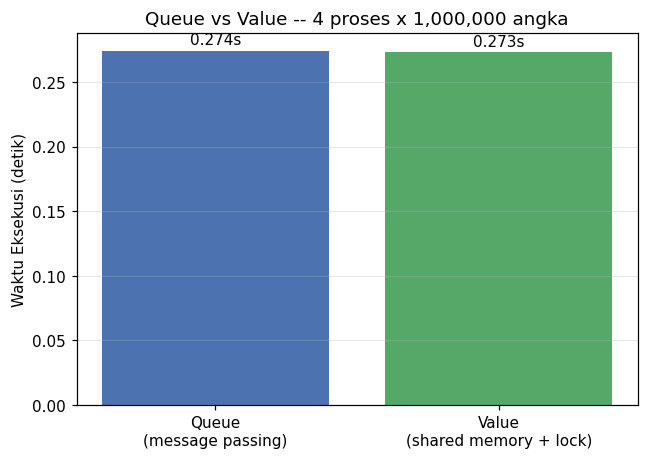

In [8]:
import matplotlib.pyplot as plt

metode = ["Queue\n(message passing)", "Value\n(shared memory + lock)"]
waktu = [waktu_queue, waktu_value]

plt.figure(figsize=(6, 4.3))
bars = plt.bar(metode, waktu, color=["#4C72B0", "#55A868"])
for b, w in zip(bars, waktu):
    plt.text(b.get_x() + b.get_width()/2, w + 0.005, f"{w:.3f}s", ha='center')
plt.ylabel("Waktu Eksekusi (detik)")
plt.title(f"Queue vs Value -- {JUMLAH_PROSES} proses x {JUMLAH_ANGKA:,} angka")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Perbandingan & Penjelasan:**

Kedua versi menghasilkan total yang sama, sehingga keduanya terbukti benar. Pada percobaan ini, Value sedikit lebih cepat daripada Queue karena Queue membutuhkan proses serialisasi dan pengiriman data melalui IPC, sedangkan Value menggunakan memori bersama sehingga data dapat diakses langsung. Namun, karena hanya satu nilai subtotal yang dikirim dari setiap proses, perbedaan waktunya relatif kecil dan sebagian besar waktu tetap digunakan untuk menghitung 1 juta angka acak. Jadi, untuk data kecil dan pengiriman yang jarang, Queue dan Value sama-sama praktis, sedangkan perbedaannya akan lebih terasa jika data dikirim atau diakses berulang kali.


## 3. Producer-Consumer Antar-Proses

**Soal:** Modifikasi contoh producer-consumer queue.Queue dari Pertemuan 2 (yang berbasis thread) menjadi berbasis multiprocessing.Queue dan multiprocessing.Process. Apakah pola kode secara struktur banyak berubah? Apa perbedaan performa yang kalian amati untuk tugas yang CPU-bound (bukan I/O-bound seperti di Pertemuan 2)?

Supaya perbandingannya bermakna, tugas yang dikerjakan consumer diganti dari time.sleep() (I/O-bound, seperti versi aslinya) menjadi pekerjaan CPU-bound sungguhan: menghitung jumlah bilangan prima . Fungsi producer/consumer-nya sendiri dibuat identik strukturnya antara versi thread dan versi proses hanya kelas yang dipakai yang berbeda.

In [9]:
JUMLAH_ITEM = 6
N_PRIMA = 60_000   # ukuran kerja CPU-bound per item (cukup berat supaya perbedaannya jelas)


In [ ]:
# Versi THREADING 
import threading
import queue as pyqueue
import time

def producer_thread(q, jumlah_item):
    for i in range(jumlah_item):
        q.put(i)
        print(f"[Producer-Thread] menghasilkan item-{i}")
    q.put(None)

def consumer_thread(q, nama="Consumer-Thread"):
    while True:
        item = q.get()
        if item is None:
            q.put(None)
            break
        hasil = hitung_prima(N_PRIMA)   # <-- kerja CPU-bound sungguhan, bukan time.sleep
        print(f"    [{nama}] item-{item} -> jumlah prima di bawah {N_PRIMA}: {hasil}")

q_thread = pyqueue.Queue()
start = time.perf_counter()

t_producer = threading.Thread(target=producer_thread, args=(q_thread, JUMLAH_ITEM))
t_consumer = threading.Thread(target=consumer_thread, args=(q_thread,))
t_producer.start()
t_consumer.start()
t_producer.join()
t_consumer.join()

waktu_threading = time.perf_counter() - start
print(f"\nTotal waktu (threading, CPU-bound): {waktu_threading:.3f} detik")


[Producer-Thread] menghasilkan item-0
[Producer-Thread] menghasilkan item-1
[Producer-Thread] menghasilkan item-2
[Producer-Thread] menghasilkan item-3
[Producer-Thread] menghasilkan item-4
[Producer-Thread] menghasilkan item-5
    [Consumer-Thread] item-0 -> jumlah prima di bawah 60000: 6057
    [Consumer-Thread] item-1 -> jumlah prima di bawah 60000: 6057
    [Consumer-Thread] item-2 -> jumlah prima di bawah 60000: 6057
    [Consumer-Thread] item-3 -> jumlah prima di bawah 60000: 6057
    [Consumer-Thread] item-4 -> jumlah prima di bawah 60000: 6057
    [Consumer-Thread] item-5 -> jumlah prima di bawah 60000: 6057

Total waktu (threading, CPU-bound): 0.240 detik


In [ ]:
# Versi MULTIPROCESSING 
import multiprocessing as mp

def producer_proc(q, jumlah_item):
    for i in range(jumlah_item):
        q.put(i)
        print(f"[Producer-Proc] menghasilkan item-{i}")
    q.put(None)

def consumer_proc(q, nama="Consumer-Proc"):
    while True:
        item = q.get()
        if item is None:
            q.put(None)
            break
        hasil = hitung_prima(N_PRIMA)   # kerja CPU-bound yang SAMA PERSIS seperti versi thread
        print(f"    [{nama}] item-{item} -> jumlah prima di bawah {N_PRIMA}: {hasil}")

if __name__ == "__main__":
    q_proc = mp.Queue()
    start = time.perf_counter()

    p_producer = mp.Process(target=producer_proc, args=(q_proc, JUMLAH_ITEM))
    p_consumer = mp.Process(target=consumer_proc, args=(q_proc,))
    p_producer.start()
    p_consumer.start()
    p_producer.join()
    p_consumer.join()

    waktu_multiprocessing = time.perf_counter() - start
    print(f"\nTotal waktu (multiprocessing, CPU-bound): {waktu_multiprocessing:.3f} detik")


[Producer-Proc] menghasilkan item-0
[Producer-Proc] menghasilkan item-1
[Producer-Proc] menghasilkan item-2
[Producer-Proc] menghasilkan item-3
[Producer-Proc] menghasilkan item-4
[Producer-Proc] menghasilkan item-5
    [Consumer-Proc] item-0 -> jumlah prima di bawah 60000: 6057
    [Consumer-Proc] item-1 -> jumlah prima di bawah 60000: 6057
    [Consumer-Proc] item-2 -> jumlah prima di bawah 60000: 6057
    [Consumer-Proc] item-3 -> jumlah prima di bawah 60000: 6057
    [Consumer-Proc] item-4 -> jumlah prima di bawah 60000: 6057
    [Consumer-Proc] item-5 -> jumlah prima di bawah 60000: 6057

Total waktu (multiprocessing, CPU-bound): 0.246 detik


Hasil dengan 1 producer + 1 consumer di atas: waktu threading (≈0.24 detik) dan multiprocessing (≈0.26 detik) hampir sama, multiprocessing malah sedikit lebih lambat. Ini  hanya ada satu consumer, jadi hanya ada satu unit eksekusi yang benar-benar mengerjakan tugas CPU-bound di satu waktu GIL tidak sempat jadi penghalang karena memang tidak ada thread lain yang butuh CPU secara bersamaan untuk diperlambat olehnya. multiprocessing di sini hanya menambah overhead pembuatan proses tanpa ada manfaat paralelisme untuk ditukar.


In [ ]:
# 3 consumer versi THREADING 
def consumer_thread3(q, nama):
    while True:
        item = q.get()
        if item is None:
            q.put(None)
            break
        hasil = hitung_prima(N_PRIMA)
        print(f"    [{nama}] item-{item} -> {hasil} prima")

JUMLAH_ITEM_3C = 12
JUMLAH_CONSUMER = 3

q3_thread = pyqueue.Queue()
start = time.perf_counter()

tp = threading.Thread(target=producer_thread, args=(q3_thread, JUMLAH_ITEM_3C))
tcs = [threading.Thread(target=consumer_thread3, args=(q3_thread, f"T-Consumer-{i+1}")) for i in range(JUMLAH_CONSUMER)]
tp.start()
for t in tcs: t.start()
tp.join()
for t in tcs: t.join()

waktu_threading_3c = time.perf_counter() - start
print(f"\nTotal waktu (threading, 3 consumer, CPU-bound): {waktu_threading_3c:.3f} detik")


[Producer-Thread] menghasilkan item-0
[Producer-Thread] menghasilkan item-1
[Producer-Thread] menghasilkan item-2
[Producer-Thread] menghasilkan item-3
[Producer-Thread] menghasilkan item-4
[Producer-Thread] menghasilkan item-5
[Producer-Thread] menghasilkan item-6
[Producer-Thread] menghasilkan item-7
[Producer-Thread] menghasilkan item-8
[Producer-Thread] menghasilkan item-9
[Producer-Thread] menghasilkan item-10
[Producer-Thread] menghasilkan item-11
    [T-Consumer-1] item-0 -> 6057 prima    [T-Consumer-2] item-1 -> 6057 prima

    [T-Consumer-3] item-2 -> 6057 prima
    [T-Consumer-2] item-3 -> 6057 prima    [T-Consumer-1] item-4 -> 6057 prima

    [T-Consumer-3] item-5 -> 6057 prima
    [T-Consumer-2] item-6 -> 6057 prima
    [T-Consumer-1] item-7 -> 6057 prima
    [T-Consumer-3] item-8 -> 6057 prima
    [T-Consumer-2] item-10 -> 6057 prima    [T-Consumer-1] item-9 -> 6057 prima

    [T-Consumer-3] item-11 -> 6057 prima

Total waktu (threading, 3 consumer, CPU-bound): 0.480 detik

In [ ]:
# 3 consumer versi MULTIPROCESSING 
def consumer_proc3(q, nama):
    while True:
        item = q.get()
        if item is None:
            q.put(None)
            break
        hasil = hitung_prima(N_PRIMA)
        print(f"    [{nama}] item-{item} -> {hasil} prima")

if __name__ == "__main__":
    q3_proc = mp.Queue()
    start = time.perf_counter()

    pp = mp.Process(target=producer_proc, args=(q3_proc, JUMLAH_ITEM_3C))
    pcs = [mp.Process(target=consumer_proc3, args=(q3_proc, f"P-Consumer-{i+1}")) for i in range(JUMLAH_CONSUMER)]
    pp.start()
    for p in pcs: p.start()
    pp.join()
    for p in pcs: p.join()

    waktu_mp_3c = time.perf_counter() - start
    print(f"\nTotal waktu (multiprocessing, 3 consumer, CPU-bound): {waktu_mp_3c:.3f} detik")


[Producer-Proc] menghasilkan item-0
[Producer-Proc] menghasilkan item-1
[Producer-Proc] menghasilkan item-2
[Producer-Proc] menghasilkan item-3
[Producer-Proc] menghasilkan item-4
[Producer-Proc] menghasilkan item-5
[Producer-Proc] menghasilkan item-6
[Producer-Proc] menghasilkan item-7
[Producer-Proc] menghasilkan item-8
[Producer-Proc] menghasilkan item-9
[Producer-Proc] menghasilkan item-10
[Producer-Proc] menghasilkan item-11
    [P-Consumer-2] item-0 -> 6057 prima    [P-Consumer-1] item-1 -> 6057 prima

    [P-Consumer-3] item-2 -> 6057 prima
    [P-Consumer-1] item-3 -> 6057 prima    [P-Consumer-2] item-4 -> 6057 prima

    [P-Consumer-3] item-5 -> 6057 prima
    [P-Consumer-2] item-6 -> 6057 prima    [P-Consumer-1] item-7 -> 6057 prima
    [P-Consumer-3] item-8 -> 6057 prima

    [P-Consumer-2] item-9 -> 6057 prima    [P-Consumer-1] item-10 -> 6057 prima    [P-Consumer-3] item-11 -> 6057 prima



Total waktu (multiprocessing, 3 consumer, CPU-bound): 0.507 detik


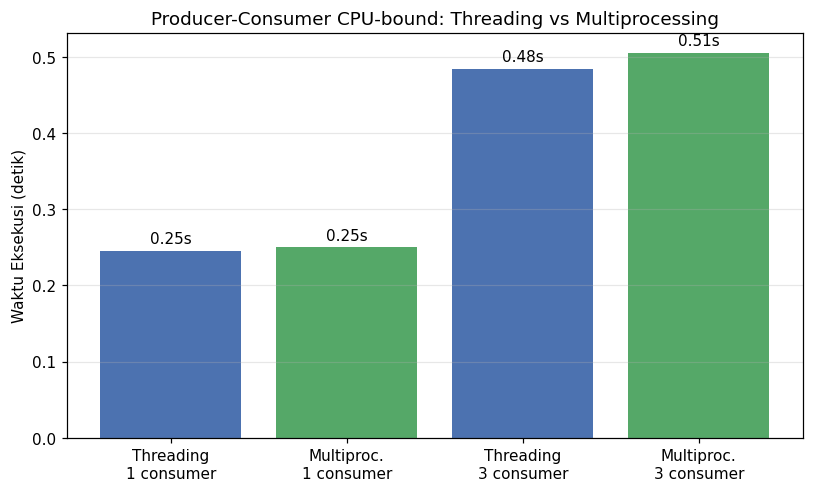

In [14]:
import matplotlib.pyplot as plt

label = ["Threading\n1 consumer", "Multiproc.\n1 consumer", "Threading\n3 consumer", "Multiproc.\n3 consumer"]
nilai = [waktu_threading, waktu_multiprocessing, waktu_threading_3c, waktu_mp_3c]
warna = ["#4C72B0", "#55A868", "#4C72B0", "#55A868"]

plt.figure(figsize=(7.5, 4.6))
bars = plt.bar(label, nilai, color=warna)
for b, w in zip(bars, nilai):
    plt.text(b.get_x() + b.get_width()/2, w + 0.01, f"{w:.2f}s", ha="center")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title("Producer-Consumer CPU-bound: Threading vs Multiprocessing")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Apakah pola kode secara struktur banyak berubah?** 
Secara struktur, kode threading dan multiprocessing tidak banyak berubah. Perubahan utamanya hanya pada penggunaan Queue dan Thread menjadi multiprocessing.Queue dan multiprocessing.Process, sedangkan .start() dan .join() tetap sama. Logika producer dan consumer juga tetap sama. Perbedaannya, multiprocessing membutuhkan if __name__ == "__main__":. Dari sisi performa, pada mesin ini multiprocessing belum lebih cepat karena jumlah core terbatas dan adanya overhead pembuatan proses. Namun, pada mesin dengan banyak core, multiprocessing lebih efektif untuk tugas CPU-bound karena beberapa proses dapat berjalan secara paralel, sedangkan threading dibatasi oleh GIL.
